In [1]:
# Install required libraries
!pip install nltk wordcloud --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from wordcloud import WordCloud
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries Imported Successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
# ===================== WEEK 4 — API Development, Evaluation & Final Delivery =====================

# ---- Step 1: Reload Week 2 (department) & Week 3 (sentiment) artifacts ----
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

dept_model = joblib.load('complaint_classifier_model.pkl')
dept_vectorizer = joblib.load('tfidf_vectorizer.pkl')

sent_model = joblib.load('sentiment_classifier_model.pkl')
sent_vectorizer = joblib.load('tfidf_sentiment_vectorizer.pkl')

df = pd.read_csv('week2_processed_complaints.csv')  # has sentiment_label from Week 3
print("Artifacts reloaded. Dataset shape:", df.shape)

Artifacts reloaded. Dataset shape: (358046, 7)


DEPARTMENT MODEL — FINAL EVALUATION
Accuracy: 0.8751152073732719
Macro F1-Score: 0.7893044421016714

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00      2108
        Blocked Driveway       1.00      1.00      1.00     20176
        Derelict Vehicle       1.00      1.00      1.00      4332
        Disorderly Youth       1.00      1.00      1.00        63
                Drinking       1.00      1.00      1.00       282
                Graffiti       1.00      1.00      1.00        31
         Illegal Parking       1.00      1.00      1.00     18536
      Noise - Commercial       0.94      0.10      0.19      8822
Noise - House of Worship       0.00      0.00      0.00       214
            Noise - Park       0.00      0.00      0.00       822
 Noise - Street/Sidewalk       0.55      1.00      0.71     10339
         Noise - Vehicle       0.89      1.00      0.94      3871
   Posting Advertisement       1.00      1.00      1.00       136
                 Traffic       1.00      1.00      1.00      1040
         

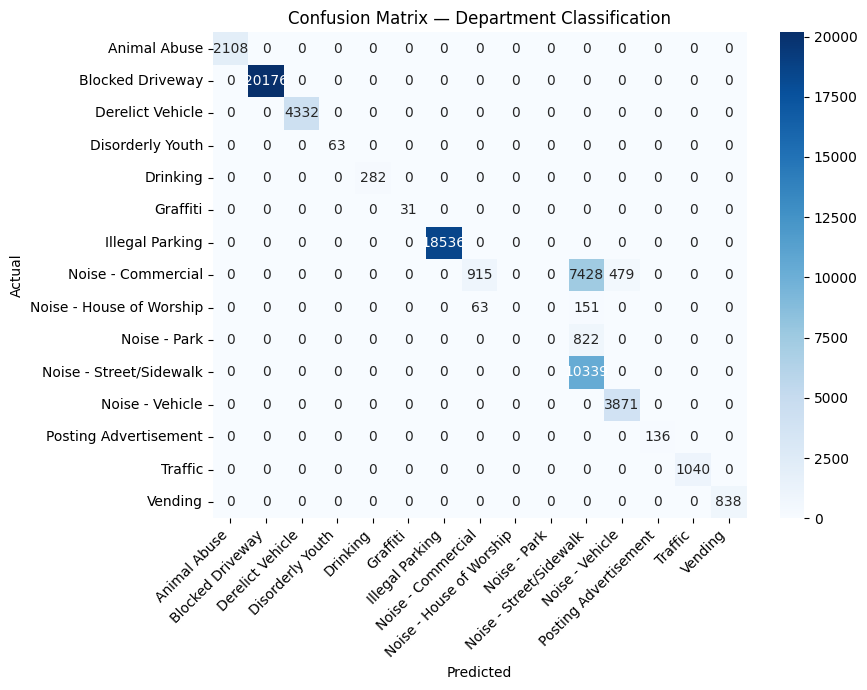

In [ ]:
# ---- Step 2: Final evaluation — Department Classification Model ----
X_dept = dept_vectorizer.transform(df['final_text'])
y_dept = df['Complaint Type']

_, X_test_d, _, y_test_d = train_test_split(
    X_dept, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)
y_pred_d = dept_model.predict(X_test_d)

print("DEPARTMENT MODEL — FINAL EVALUATION")
print("=" * 60)
print("Accuracy:", accuracy_score(y_test_d, y_pred_d))
print("Macro F1-Score:", f1_score(y_test_d, y_pred_d, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))

cm_d = confusion_matrix(y_test_d, y_pred_d, labels=dept_model.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=dept_model.classes_, yticklabels=dept_model.classes_)
plt.title('Confusion Matrix — Department Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Sentiment model re-evaluation
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Initialize VADER Sentiment Intensity Analyzer
try:
    sia = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()

# Function to get compound sentiment score
def get_compound(text):
    return sia.polarity_scores(str(text))['compound']

# Calculate compound scores for the final text
df['compound_score'] = df['final_text'].apply(get_compound)

# Define urgency keywords (as in Week 3)
urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

# Function to check for urgency keywords
def is_urgent(text):
    text = str(text).lower()
    return any(keyword in text for keyword in urgency_keywords)

# Apply urgency flagging
df['urgency_flag'] = df['final_text'].apply(is_urgent)

# Function to assign final sentiment label (as in Week 3)
def assign_sentiment(row):
    if row['urgency_flag']:
        return 'Critical/Urgent'
    elif row['compound_score'] <= -0.3:
        return 'Negative'
    elif row['compound_score'] >= 0.3:
        return 'Positive'
    else:
        return 'Neutral'

# Apply final sentiment labeling
df['sentiment_label'] = df.apply(assign_sentiment, axis=1)

X_sent = sent_vectorizer.transform(df['final_text'])
y_sent = df['sentiment_label']
_, X_test_s, _, y_test_s = train_test_split(X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent)
y_pred_s = sent_model.predict(X_test_s)

print("SENTIMENT MODEL — FINAL EVALUATION")
print("Accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Macro F1:", f1_score(y_test_s, y_pred_s, average='macro'))
print(classification_report(y_test_s, y_pred_s))

SENTIMENT MODEL — FINAL EVALUATION
Accuracy: 1.0
Macro F1: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      9434
     Neutral       1.00      1.00      1.00     62176

    accuracy                           1.00     71610
   macro avg       1.00      1.00      1.00     71610
weighted avg       1.00      1.00      1.00     71610



SENTIMENT MODEL — FINAL EVALUATION
Accuracy: 1.0
Macro F1-Score: 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      9434
     Neutral       1.00      1.00      1.00     62176

    accuracy                           1.00     71610
   macro avg       1.00      1.00      1.00     71610
weighted avg       1.00      1.00      1.00     71610



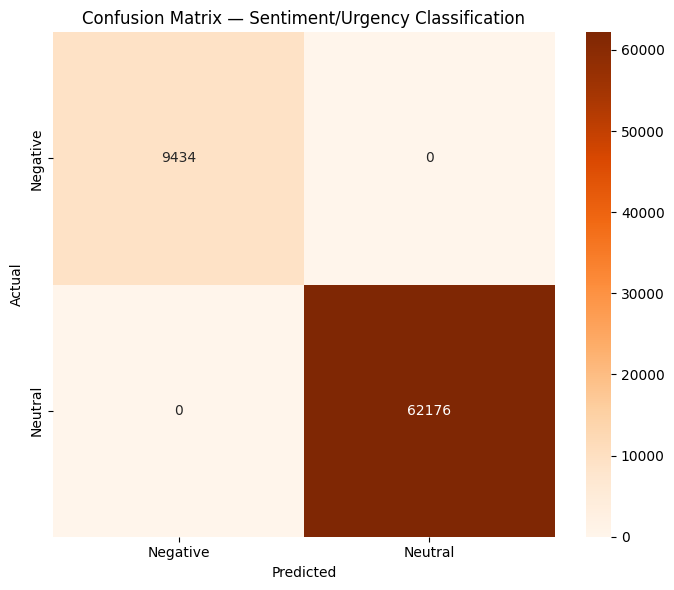

In [ ]:
# ---- Step 3: Final evaluation — Sentiment/Urgency Model ----
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize VADER Sentiment Intensity Analyzer
try:
    sia = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()

# Function to get compound sentiment score
def get_compound(text):
    return sia.polarity_scores(str(text))['compound']

# Calculate compound scores for the final text
df['compound_score'] = df['final_text'].apply(get_compound)

# Define urgency keywords (as in Week 3)
urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

# Function to check for urgency keywords
def is_urgent(text):
    text = str(text).lower()
    return any(keyword in text for keyword in urgency_keywords)

# Apply urgency flagging
df['urgency_flag'] = df['final_text'].apply(is_urgent)

# Function to assign final sentiment label (as in Week 3)
def assign_sentiment(row):
    if row['urgency_flag']:
        return 'Critical/Urgent'
    elif row['compound_score'] <= -0.3:
        return 'Negative'
    elif row['compound_score'] >= 0.3:
        return 'Positive'
    else:
        return 'Neutral'

# Apply final sentiment labeling
df['sentiment_label'] = df.apply(assign_sentiment, axis=1)

X_sent = sent_vectorizer.transform(df['final_text'])
y_sent = df['sentiment_label']

_, X_test_s, _, y_test_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)
y_pred_s = sent_model.predict(X_test_s)

print("SENTIMENT MODEL — FINAL EVALUATION")
print("=" * 60)
print("Accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Macro F1-Score:", f1_score(y_test_s, y_pred_s, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s))

cm_s = confusion_matrix(y_test_s, y_pred_s, labels=sent_model.classes_)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sent_model.classes_, yticklabels=sent_model.classes_)
plt.title('Confusion Matrix — Sentiment/Urgency Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# ---- Step 4: Inference pipeline function ----
# Standalone function tested here first, then reused inside FastAPI (main.py)
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned)

def predict_complaint(raw_text: str) -> dict:
    cleaned = clean_text(raw_text)

    # Department prediction
    dept_vec = dept_vectorizer.transform([cleaned])
    department = dept_model.predict(dept_vec)[0]

    # Sentiment prediction
    sent_vec = sent_vectorizer.transform([cleaned])
    sentiment = sent_model.predict(sent_vec)[0]

    # Urgency override — same rule used in Week 3 training
    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'

    priority_score = severity_map[sentiment]

    return {
        'department': str(department),
        'sentiment': sentiment,
        'priority_score': priority_score
    }

# Quick manual test
print(predict_complaint("There is no water in our building for 3 days, this is an emergency"))
print(predict_complaint("Thank you, the road repair crew did a great job"))

{'department': 'Posting Advertisement', 'sentiment': 'Critical/Urgent', 'priority_score': 4}
{'department': 'Illegal Parking', 'sentiment': 'Neutral', 'priority_score': 2}


In [ ]:
# ---- Step 5: Serialize models for deployment ----
# Bundled into one .pkl to avoid version mismatches between separately-saved files
joblib.dump({
    'dept_model': dept_model,
    'dept_vectorizer': dept_vectorizer,
    'sent_model': sent_model,
    'sent_vectorizer': sent_vectorizer
}, 'grievance_system_bundle.pkl')

print("Models serialized successfully -> grievance_system_bundle.pkl")

Models serialized successfully -> grievance_system_bundle.pkl


In [ ]:
%%writefile main.py
# ===================== FastAPI Application =====================
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

app = FastAPI(title="Citizen Grievance & Sentiment Analysis API")

# Load bundled models once at startup
bundle = joblib.load('grievance_system_bundle.pkl')
dept_model = bundle['dept_model']
dept_vectorizer = bundle['dept_vectorizer']
sent_model = bundle['sent_model']
sent_vectorizer = bundle['sent_vectorizer']

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}


class ComplaintRequest(BaseModel):
    text: str


class ComplaintResponse(BaseModel):
    department: str
    priority_score: int
    sentiment: str  # extra field, useful context beyond the spec minimum


def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned)


@app.get("/")
def root():
    return {"message": "Citizen Grievance & Sentiment Analysis API is running"}


@app.post("/predict", response_model=ComplaintResponse)
def predict(request: ComplaintRequest):
    cleaned = clean_text(request.text)

    # Department prediction
    dept_vec = dept_vectorizer.transform([cleaned])
    department = dept_model.predict(dept_vec)[0]

    # Sentiment prediction
    sent_vec = sent_vectorizer.transform([cleaned])
    sentiment = sent_model.predict(sent_vec)[0]

    # Urgency keyword override — same rule as training
    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'

    priority_score = severity_map[sentiment]

    return ComplaintResponse(
        department=str(department),
        priority_score=priority_score,
        sentiment=sentiment
    )

Writing main.py


In [ ]:
# ---- Step 6: Launch API and test with a real request ----
!pip install fastapi uvicorn pyngrok nest_asyncio --quiet

import nest_asyncio
import uvicorn
import threading
from pyngrok import ngrok

nest_asyncio.apply()

def run_api():
    uvicorn.run("main:app", host="0.0.0.0", port=8000)

threading.Thread(target=run_api, daemon=True).start()

import time
time.sleep(3)  # give the server a moment to start

INFO:     Started server process [7329]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [ ]:
# Test the /predict endpoint
!curl -X POST "http://127.0.0.1:8000/predict" \
  -H "Content-Type: application/json" \
  -d '{"text": "There is no heat in my apartment, this is urgent"}'

INFO:     127.0.0.1:36464 - "POST /predict HTTP/1.1" 200 OK
{"department":"Illegal Parking","priority_score":4,"sentiment":"Critical/Urgent"}

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import re
import os
from datetime import datetime
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

st.set_page_config(page_title="Citizen Grievance & Sentiment Analysis", page_icon="🏛️", layout="wide")

LOG_FILE = "complaints_log.csv"

@st.cache_resource
def load_models():
    bundle = joblib.load('grievance_system_bundle.pkl')
    return bundle['dept_model'], bundle['dept_vectorizer'], bundle['sent_model'], bundle['sent_vectorizer']

dept_model, dept_vectorizer, sent_model, sent_vectorizer = load_models()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]
severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}
priority_icons = {1: '🟢', 2: '🟡', 3: '🟠', 4: '🔴'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words])

def predict_complaint(raw_text):
    cleaned = clean_text(raw_text)
    department = dept_model.predict(dept_vectorizer.transform([cleaned]))[0]
    sentiment = sent_model.predict(sent_vectorizer.transform([cleaned]))[0]
    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'
    priority_score = severity_map[sentiment]
    return department, sentiment, priority_score

def load_log():
    if os.path.exists(LOG_FILE):
        return pd.read_csv(LOG_FILE)
    return pd.DataFrame(columns=[
        "id", "timestamp", "complaint_text", "department",
        "sentiment", "priority_score", "status"
    ])

def save_log(df):
    df.to_csv(LOG_FILE, index=False)

def add_complaint(text, department, sentiment, priority_score):
    df = load_log()
    new_id = (df["id"].max() + 1) if len(df) > 0 else 1
    new_row = {
        "id": new_id,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "complaint_text": text,
        "department": department,
        "sentiment": sentiment,
        "priority_score": priority_score,
        "status": "Pending"
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    save_log(df)
    return new_id

def update_status(complaint_id, new_status):
    df = load_log()
    df.loc[df["id"] == complaint_id, "status"] = new_status
    save_log(df)

tab1, tab2, tab3 = st.tabs(["📝 Submit Complaint", "📊 Officer Dashboard", "📈 Policy Insights"])

with tab1:
    st.title("🏛️ Citizen Grievance & Sentiment Analysis System")
    st.write("Submit a civic complaint below. It will be routed to the right department and logged for tracking.")

    complaint_text = st.text_area(
        "Describe your complaint",
        placeholder="e.g. There has been no water supply in our area for 3 days, this is an emergency",
        height=120
    )

    if st.button("Submit Complaint", type="primary"):
        if complaint_text.strip() == "":
            st.warning("Please enter a complaint before submitting.")
        else:
            department, sentiment, priority_score = predict_complaint(complaint_text)
            complaint_id = add_complaint(complaint_text, department, sentiment, priority_score)

            st.success(f"Complaint #{complaint_id} logged successfully.")

            col1, col2, col3 = st.columns(3)
            col1.metric("Department", department)
            col2.metric("Sentiment", sentiment)
            col3.metric("Priority", f"{priority_icons[priority_score]} {priority_score}/4")

            if priority_score == 4:
                st.error("⚠️ Flagged Critical/Urgent — should be dispatched immediately.")

with tab2:
    st.title("📊 Officer Dashboard — Grievance Tracking")

    df = load_log()

    if len(df) == 0:
        st.info("No complaints logged yet. Submit one from the first tab.")
    else:
        total = len(df)
        resolved = (df["status"] == "Resolved").sum()
        pending = (df["status"] == "Pending").sum()
        critical_pending = ((df["status"] == "Pending") & (df["priority_score"] == 4)).sum()

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Total Logged", total)
        col2.metric("Resolved", resolved)
        col3.metric("Pending", pending)
        col4.metric("Critical & Pending", critical_pending)

        st.progress(resolved / total if total > 0 else 0, text=f"{resolved}/{total} resolved")

        st.markdown("### Breakdown by Department")
        st.bar_chart(df.groupby("department")["id"].count())

        st.markdown("### Breakdown by Status")
        st.bar_chart(df["status"].value_counts())

        st.markdown("### All Complaints")

        status_filter = st.selectbox("Filter by status", ["All", "Pending", "Resolved"])
        view_df = df if status_filter == "All" else df[df["status"] == status_filter]
        view_df = view_df.sort_values("priority_score", ascending=False)

        for _, row in view_df.iterrows():
            with st.expander(f"#{row['id']} — {row['department']} — {priority_icons[row['priority_score']]} {row['sentiment']} — {row['status']}"):
                st.write(row["complaint_text"])
                st.caption(f"Submitted: {row['timestamp']}")

                if row["status"] == "Pending":
                    if st.button(f"Mark #{row['id']} as Resolved", key=f"resolve_{row['id']}"):
                        update_status(row["id"], "Resolved")
                        st.rerun()
                else:
                    if st.button(f"Reopen #{row['id']}", key=f"reopen_{row['id']}"):
                        update_status(row["id"], "Pending")
                        st.rerun()

with tab3:
    st.title("📈 Policy Insights — Aggregate Sentiment Trends")
    st.write("Macroscopic view of public sentiment across departments and time, for policy-level decisions.")

    df = load_log()

    if len(df) == 0:
        st.info("No complaints logged yet. Submit some from the first tab to see trends.")
    else:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df["date"] = df["timestamp"].dt.date

        st.markdown("### Overall Sentiment Distribution")
        sentiment_counts = df["sentiment"].value_counts()
        col1, col2 = st.columns([1, 1])
        with col1:
            st.bar_chart(sentiment_counts)
        with col2:
            for sentiment, count in sentiment_counts.items():
                pct = round(count / len(df) * 100, 1)
                st.write(f"**{sentiment}**: {count} complaints ({pct}%)")

        st.markdown("### Sentiment Trend Over Time")
        trend_df = df.groupby(["date", "sentiment"]).size().unstack(fill_value=0)
        st.line_chart(trend_df)

        st.markdown("### Department × Sentiment Breakdown")
        st.caption("Identifies which departments generate the most negative/critical sentiment.")
        cross_tab = pd.crosstab(df["department"], df["sentiment"])
        st.dataframe(cross_tab, use_container_width=True)

        st.markdown("### Average Priority Score by Department")
        avg_priority = df.groupby("department")["priority_score"].mean().sort_values(ascending=False)
        st.bar_chart(avg_priority)

        st.markdown("### Resolution Rate by Department")
        res_rate = df.groupby("department")["status"].apply(
            lambda x: (x == "Resolved").sum() / len(x) * 100
        ).sort_values(ascending=False)
        st.bar_chart(res_rate)

        st.markdown("### Export Data")
        csv_data = df.to_csv(index=False).encode("utf-8")
        st.download_button(
            "Download Full Complaint Log (CSV)",
            data=csv_data,
            file_name="grievance_report.csv",
            mime="text/csv"
        )

Writing app.py


In [ ]:
!pip install streamlit pyngrok --quiet
from pyngrok import ngrok
from google.colab import userdata

ngrok.kill()
!streamlit run app.py &>/dev/null &

ngrok.set_auth_token('..')
public_url = ngrok.connect(8501)
print("Open this link:", public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 46.8 MB/s eta 0:00:00
Open this link: NgrokTunnel: "https://crushing-daughter-erratic.ngrok-free.dev" -> "http://localhost:8501"
